# Kang IFNb CD14 Monocyte Gene Program Analysis

This notebook identifies gene programs differentiating IFNb response in CD14+ monocytes between `ctrl` and `stim` cells. It combines a raw-expression sanity check with a CD14-only spVIPESmulti model, then interprets stimulated private latent factors as treatment-specific gene programs.

The response readout is treated as a donor-adjusted gradient rather than only a hard `ISG_score > 5` class. That makes the analysis less sensitive to donor-specific score shifts.

In [1]:
import sys
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import torch
from scipy.stats import spearmanr
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import balanced_accuracy_score, roc_auc_score
from sklearn.model_selection import train_test_split


def find_repo_root(start=Path.cwd()):
    start = Path(start).resolve()
    for path in (start, *start.parents):
        if (path / "src" / "spVIPESmulti").exists():
            return path
    return start


REPO_ROOT = find_repo_root()
SRC_DIR = REPO_ROOT / "src"
if SRC_DIR.exists() and str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

import spVIPESmulti

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.set_float32_matmul_precision("high")

sc.settings.set_figure_params(dpi=100, frameon=False)

RESULTS_DIR = REPO_ROOT / "docs" / "notebooks" / "results" / "kang_ifn_cd14_gene_programs"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"Repo root  : {REPO_ROOT}")
print(f"Results   : {RESULTS_DIR}")
print(f"CUDA      : {torch.cuda.is_available()}")

/exports/archive/hg-funcgenom-research/mdmanurung/conda/envs/scvi-test/lib/python3.13/site-packages/anndata/experimental/__init__.py:48: FutureWarning: Importing read_elem from `anndata.experimental` is deprecated. Import anndata.io.read_elem instead.
  return module_get_attr_redirect(


Repo root  : /exports/para-lipg-hpc/mdmanurung/spVIPESmulti
Results   : /exports/para-lipg-hpc/mdmanurung/spVIPESmulti/docs/notebooks/results/kang_ifn_cd14_gene_programs
CUDA      : True


/tmp/ipykernel_2845787/2790581601.py:39: FutureWarning: Use `scanpy.set_figure_params` instead
  sc.settings.set_figure_params(dpi=100, frameon=False)


## Helper Functions

In [2]:
IFN_BETA_RESPONSE_GENES = [
    "IFNAR1", "IFNAR2", "IFNB1", "STAT1", "STAT2", "TYK2", "JAK1",
    "IRF9", "IRF1", "IRF7", "IRF3", "OAS1", "OAS2", "OAS3", "MX1",
    "MX2", "ISG15", "RSAD2", "IFI27", "IFI44", "IFI44L", "IFIT1",
    "IFIT2", "IFIT3", "IFIT5", "IFITM1", "IFITM2", "IFITM3",
    "IFI6", "IFIH1", "IFIT1B", "IFITM10", "OASL", "BST2", "IFITM5",
]


def load_kang_2018():
    candidates = [
        REPO_ROOT / "docs" / "notebooks" / "data" / "kang_2018.h5ad",
        REPO_ROOT / "data" / "kang_2018.h5ad",
        Path.cwd() / "data" / "kang_2018.h5ad",
        Path.cwd() / "kang_2018.h5ad",
    ]
    for path in candidates:
        if path.exists() and path.stat().st_size > 0:
            print(f"Reading local Kang data: {path}")
            return sc.read_h5ad(path)

    try:
        import pertpy as pt
    except ImportError as exc:
        raise FileNotFoundError(
            "No local kang_2018.h5ad file was found, and pertpy is not installed. "
            "Place the file under docs/notebooks/data/ or install pertpy."
        ) from exc

    print("No local Kang h5ad found; loading with pertpy.")
    return pt.data.kang_2018()


def require_obs(adata, keys):
    missing = [key for key in keys if key not in adata.obs]
    if missing:
        raise KeyError(f"Missing required obs columns: {missing}")


def present_genes(adata, genes):
    return [gene for gene in genes if gene in adata.var_names]


def score_ifn_response(adata, score_name="ISG_score"):
    genes = present_genes(adata, IFN_BETA_RESPONSE_GENES)
    missing = sorted(set(IFN_BETA_RESPONSE_GENES) - set(genes))
    print(f"IFN-response genes present: {len(genes)} / {len(IFN_BETA_RESPONSE_GENES)}")
    if missing:
        print("Missing genes:", missing)
    if len(genes) < 5:
        raise ValueError("Too few IFN-response genes are present to compute a stable score.")
    sc.tl.score_genes(adata, gene_list=genes, score_name=score_name, use_raw=False)
    return genes


def add_donor_adjusted_response(
    adata,
    score_key="ISG_score",
    out_key="ISG_z_by_donor",
    strata=("label", "replicate"),
):
    def _zscore(values):
        values = values.astype(float)
        std = values.std(ddof=0)
        if not np.isfinite(std) or std == 0:
            return pd.Series(np.zeros(values.shape[0]), index=values.index)
        return (values - values.mean()) / std

    adata.obs[out_key] = (
        adata.obs.groupby(list(strata), observed=True)[score_key]
        .transform(_zscore)
        .astype(float)
    )


def add_extreme_response_labels(
    adata,
    score_key="ISG_z_by_donor",
    condition_key="label",
    stim_value="stim",
    donor_key="replicate",
    out_key="ifnb_response_extreme",
    lower_q=0.2,
    upper_q=0.8,
):
    labels = pd.Series("middle", index=adata.obs_names, dtype="object")
    labels.loc[adata.obs[condition_key].astype(str) != stim_value] = "ctrl"

    stim_obs = adata.obs[adata.obs[condition_key].astype(str) == stim_value]
    for _, idx in stim_obs.groupby(donor_key, observed=True).groups.items():
        scores = adata.obs.loc[idx, score_key].astype(float)
        low_cut = scores.quantile(lower_q)
        high_cut = scores.quantile(upper_q)
        labels.loc[scores.index[scores <= low_cut]] = "low"
        labels.loc[scores.index[scores >= high_cut]] = "high"

    adata.obs[out_key] = pd.Categorical(
        labels,
        categories=["ctrl", "low", "middle", "high"],
        ordered=True,
    )


def probe_balanced_accuracy(x, y, seed=SEED):
    y = np.asarray(y).astype(str)
    classes, counts = np.unique(y, return_counts=True)
    if classes.size < 2:
        return np.nan
    stratify = y if counts.min() >= 2 else None
    x_train, x_test, y_train, y_test = train_test_split(
        x,
        y,
        test_size=0.3,
        random_state=seed,
        stratify=stratify,
    )
    clf = LogisticRegression(max_iter=1000, class_weight="balanced")
    clf.fit(x_train, y_train)
    return balanced_accuracy_score(y_test, clf.predict(x_test))


def latent_response_summary(
    adata,
    obsm_key,
    score_key="ISG_z_by_donor",
    label_key="ifnb_response_extreme",
):
    x = np.asarray(adata.obsm[obsm_key])
    score = pd.to_numeric(adata.obs[score_key], errors="coerce").to_numpy()
    finite_score = np.isfinite(score)
    response_labels = adata.obs[label_key].astype(str).to_numpy()
    extreme = np.isin(response_labels, ["low", "high"])

    rows = []
    for dim_idx in range(x.shape[1]):
        dim = x[:, dim_idx]
        finite_dim = np.isfinite(dim)
        corr_mask = finite_score & finite_dim
        if corr_mask.sum() >= 3 and np.nanstd(dim[corr_mask]) > 0:
            rho, p_value = spearmanr(dim[corr_mask], score[corr_mask])
        else:
            rho, p_value = np.nan, np.nan

        auc = np.nan
        auc_abs = np.nan
        auc_mask = extreme & finite_dim
        if auc_mask.sum() >= 3:
            y = (response_labels[auc_mask] == "high").astype(int)
            if np.unique(y).size == 2 and np.nanstd(dim[auc_mask]) > 0:
                auc = roc_auc_score(y, dim[auc_mask])
                auc_abs = max(auc, 1.0 - auc)

        rows.append({
            "dim": dim_idx,
            "spearman_r": rho,
            "spearman_abs": abs(rho) if np.isfinite(rho) else np.nan,
            "spearman_p": p_value,
            "auc_high_vs_low": auc,
            "auc_directionless": auc_abs,
        })

    return (
        pd.DataFrame(rows)
        .sort_values(["spearman_abs", "auc_directionless"], ascending=False)
        .reset_index(drop=True)
    )


def response_program_table(top_genes_df, response_summary, n_dims=6):
    dim_info = response_summary.head(n_dims).copy()
    dim_info["dim_index"] = dim_info["dim"].astype(int)
    dim_info["dim"] = [f"Z_private_{dim}" for dim in dim_info["dim_index"]]
    table = top_genes_df.merge(dim_info, on="dim", how="inner")
    table["high_response_genes"] = [
        row.pos_genes if row.spearman_r >= 0 else row.neg_genes
        for row in table.itertuples()
    ]
    table["low_response_genes"] = [
        row.neg_genes if row.spearman_r >= 0 else row.pos_genes
        for row in table.itertuples()
    ]
    return table[[
        "dim",
        "spearman_r",
        "spearman_p",
        "auc_high_vs_low",
        "high_response_genes",
        "low_response_genes",
        "pos_genes",
        "neg_genes",
    ]]


def first_n_genes(gene_lists, n_per_list=8):
    genes = []
    for gene_list in gene_lists:
        genes.extend(list(gene_list)[:n_per_list])
    return list(dict.fromkeys(genes))

## Load Kang Data and Score IFNb Response

In [3]:
adata = load_kang_2018()
require_obs(adata, ["cell_type", "label", "replicate"])

adata = adata[adata.obs["cell_type"] != "Megakaryocytes"].copy()
adata.obs["label"] = adata.obs["label"].astype(str)
adata.obs["replicate"] = adata.obs["replicate"].astype(str)

required_conditions = {"ctrl", "stim"}
missing_conditions = required_conditions - set(adata.obs["label"].astype(str))
if missing_conditions:
    raise ValueError(f"Missing expected condition labels: {sorted(missing_conditions)}")

print(f"Shape      : {adata.shape}")
print(f"Cell types : {adata.obs['cell_type'].nunique()}")
print("\nlabel counts:")
print(adata.obs["label"].value_counts().to_string())
print("\nreplicate x label:")
print(pd.crosstab(adata.obs["replicate"], adata.obs["label"]).to_string())

Reading local Kang data: /exports/para-lipg-hpc/mdmanurung/spVIPESmulti/docs/notebooks/data/kang_2018.h5ad
Shape      : (24541, 15706)
Cell types : 7

label counts:
label
stim    12289
ctrl    12252

replicate x label:
label         ctrl  stim
replicate               
patient_101    857  1166
patient_1015  2737  2349
patient_1016  1722  1635
patient_1039   408   583
patient_107    517   524
patient_1244  1878  1461
patient_1256  2106  2022
patient_1488  2027  2549


In [4]:
response_genes_present = score_ifn_response(adata)
add_donor_adjusted_response(adata)
add_extreme_response_labels(adata)
adata.obs["ifnb_responsive_global5"] = (adata.obs["ISG_score"] > 5).astype("category")

stim = adata[adata.obs["label"] == "stim"].copy()
cd14_stim = stim[stim.obs["cell_type"] == "CD14+ Monocytes"].copy()

print("Stimulated cells with ISG_score > 5 by cell type:")
print(
    pd.crosstab(
        stim.obs["cell_type"],
        stim.obs["ifnb_responsive_global5"],
        normalize="index",
    ).round(3).to_string()
)

print("\nStimulated CD14+ Monocyte ISG_score quantiles:")
print(cd14_stim.obs["ISG_score"].astype(float).quantile([0, .1, .25, .5, .75, .9, .95, .99, 1]).to_string())

print("\nStimulated CD14+ Monocyte donor-adjusted response label counts:")
print(pd.crosstab(cd14_stim.obs["replicate"], cd14_stim.obs["ifnb_response_extreme"]).to_string())

IFN-response genes present: 34 / 35
Missing genes: ['IFITM5']
Stimulated cells with ISG_score > 5 by cell type:
ifnb_responsive_global5  False   True
cell_type                            
CD4 T cells              1.000  0.000
CD14+ Monocytes          0.624  0.376
B cells                  0.999  0.001
NK cells                 1.000  0.000
CD8 T cells              0.998  0.002
FCGR3A+ Monocytes        0.677  0.323
Dendritic cells          0.572  0.428

Stimulated CD14+ Monocyte ISG_score quantiles:
0.00    -0.307569
0.10     1.554499
0.25     2.598275
0.50     4.111147
0.75     6.028897
0.90     7.891170
0.95     9.099253
0.99    11.840582
1.00    16.381838

Stimulated CD14+ Monocyte donor-adjusted response label counts:
ifnb_response_extreme  low  middle  high
replicate                               
patient_101              0     116   153
patient_1015             0     365   353
patient_1016             2     111   242
patient_1039             0      73    91
patient_107              

## Build a CD14-only Feature Space

The model is trained only on CD14+ monocytes. We select HVGs independently across `ctrl` and `stim`, then force known IFNb-response genes to remain in the feature set so response-associated loadings are interpretable.

In [5]:
CELL_TYPE = "CD14+ Monocytes"
CONDITIONS = ["ctrl", "stim"]

adata_cd14_full = adata[adata.obs["cell_type"] == CELL_TYPE].copy()
print(f"CD14-only shape before feature selection: {adata_cd14_full.shape}")

adata_cd14_hvg = spVIPESmulti.utils.highly_variable_genes_union(
    adata_cd14_full,
    group_key="label",
    batch_key="replicate",
    n_top_genes=4000,
    flavor="seurat_v3",
)

forced_response_genes = present_genes(adata_cd14_full, IFN_BETA_RESPONSE_GENES)
selected_genes = list(dict.fromkeys(list(adata_cd14_hvg.var_names) + forced_response_genes))
adata_cd14 = adata_cd14_full[:, selected_genes].copy()

print(f"CD14-only shape after HVG union plus forced IFN genes: {adata_cd14.shape}")
print(f"Forced IFN genes retained: {len(present_genes(adata_cd14, IFN_BETA_RESPONSE_GENES))}")

CD14-only shape before feature selection: (5697, 15706)
CD14-only shape after HVG union plus forced IFN genes: (5697, 7494)
Forced IFN genes retained: 34


## Raw-expression Sanity Check

This differential-expression table is not the latent gene-program result. It checks that the expected IFNb response is visible directly in CD14 expression before fitting the model.

In [6]:
adata_de = adata_cd14.copy()
sc.pp.normalize_total(adata_de, target_sum=1e4)
sc.pp.log1p(adata_de)
sc.tl.rank_genes_groups(
    adata_de,
    groupby="label",
    groups=["stim"],
    reference="ctrl",
    method="wilcoxon",
)

de_stim_vs_ctrl = sc.get.rank_genes_groups_df(adata_de, group="stim")
de_stim_vs_ctrl.to_csv(RESULTS_DIR / "cd14_stim_vs_ctrl_de.csv", index=False)
de_stim_vs_ctrl.head(30)

,names,scores,logfoldchanges,pvals,pvals_adj
0,ISG15,65.249268,8.854693,0.0,0.0
1,IFITM3,64.773323,6.442833,0.0,0.0
2,ISG20,64.715363,6.762544,0.0,0.0
3,APOBEC3A,64.336937,6.698098,0.0,0.0
4,TNFSF10,63.547211,8.480651,0.0,0.0
5,IFIT3,63.376350,8.219893,0.0,0.0
6,LY6E,63.331291,6.638269,0.0,0.0
7,CXCL10,63.293716,10.597122,0.0,0.0
8,RSAD2,63.046051,8.552979,0.0,0.0
9,IFIT1,61.981895,8.835529,0.0,0.0


/exports/archive/hg-funcgenom-research/mdmanurung/conda/envs/scvi-test/lib/python3.13/functools.py:934: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


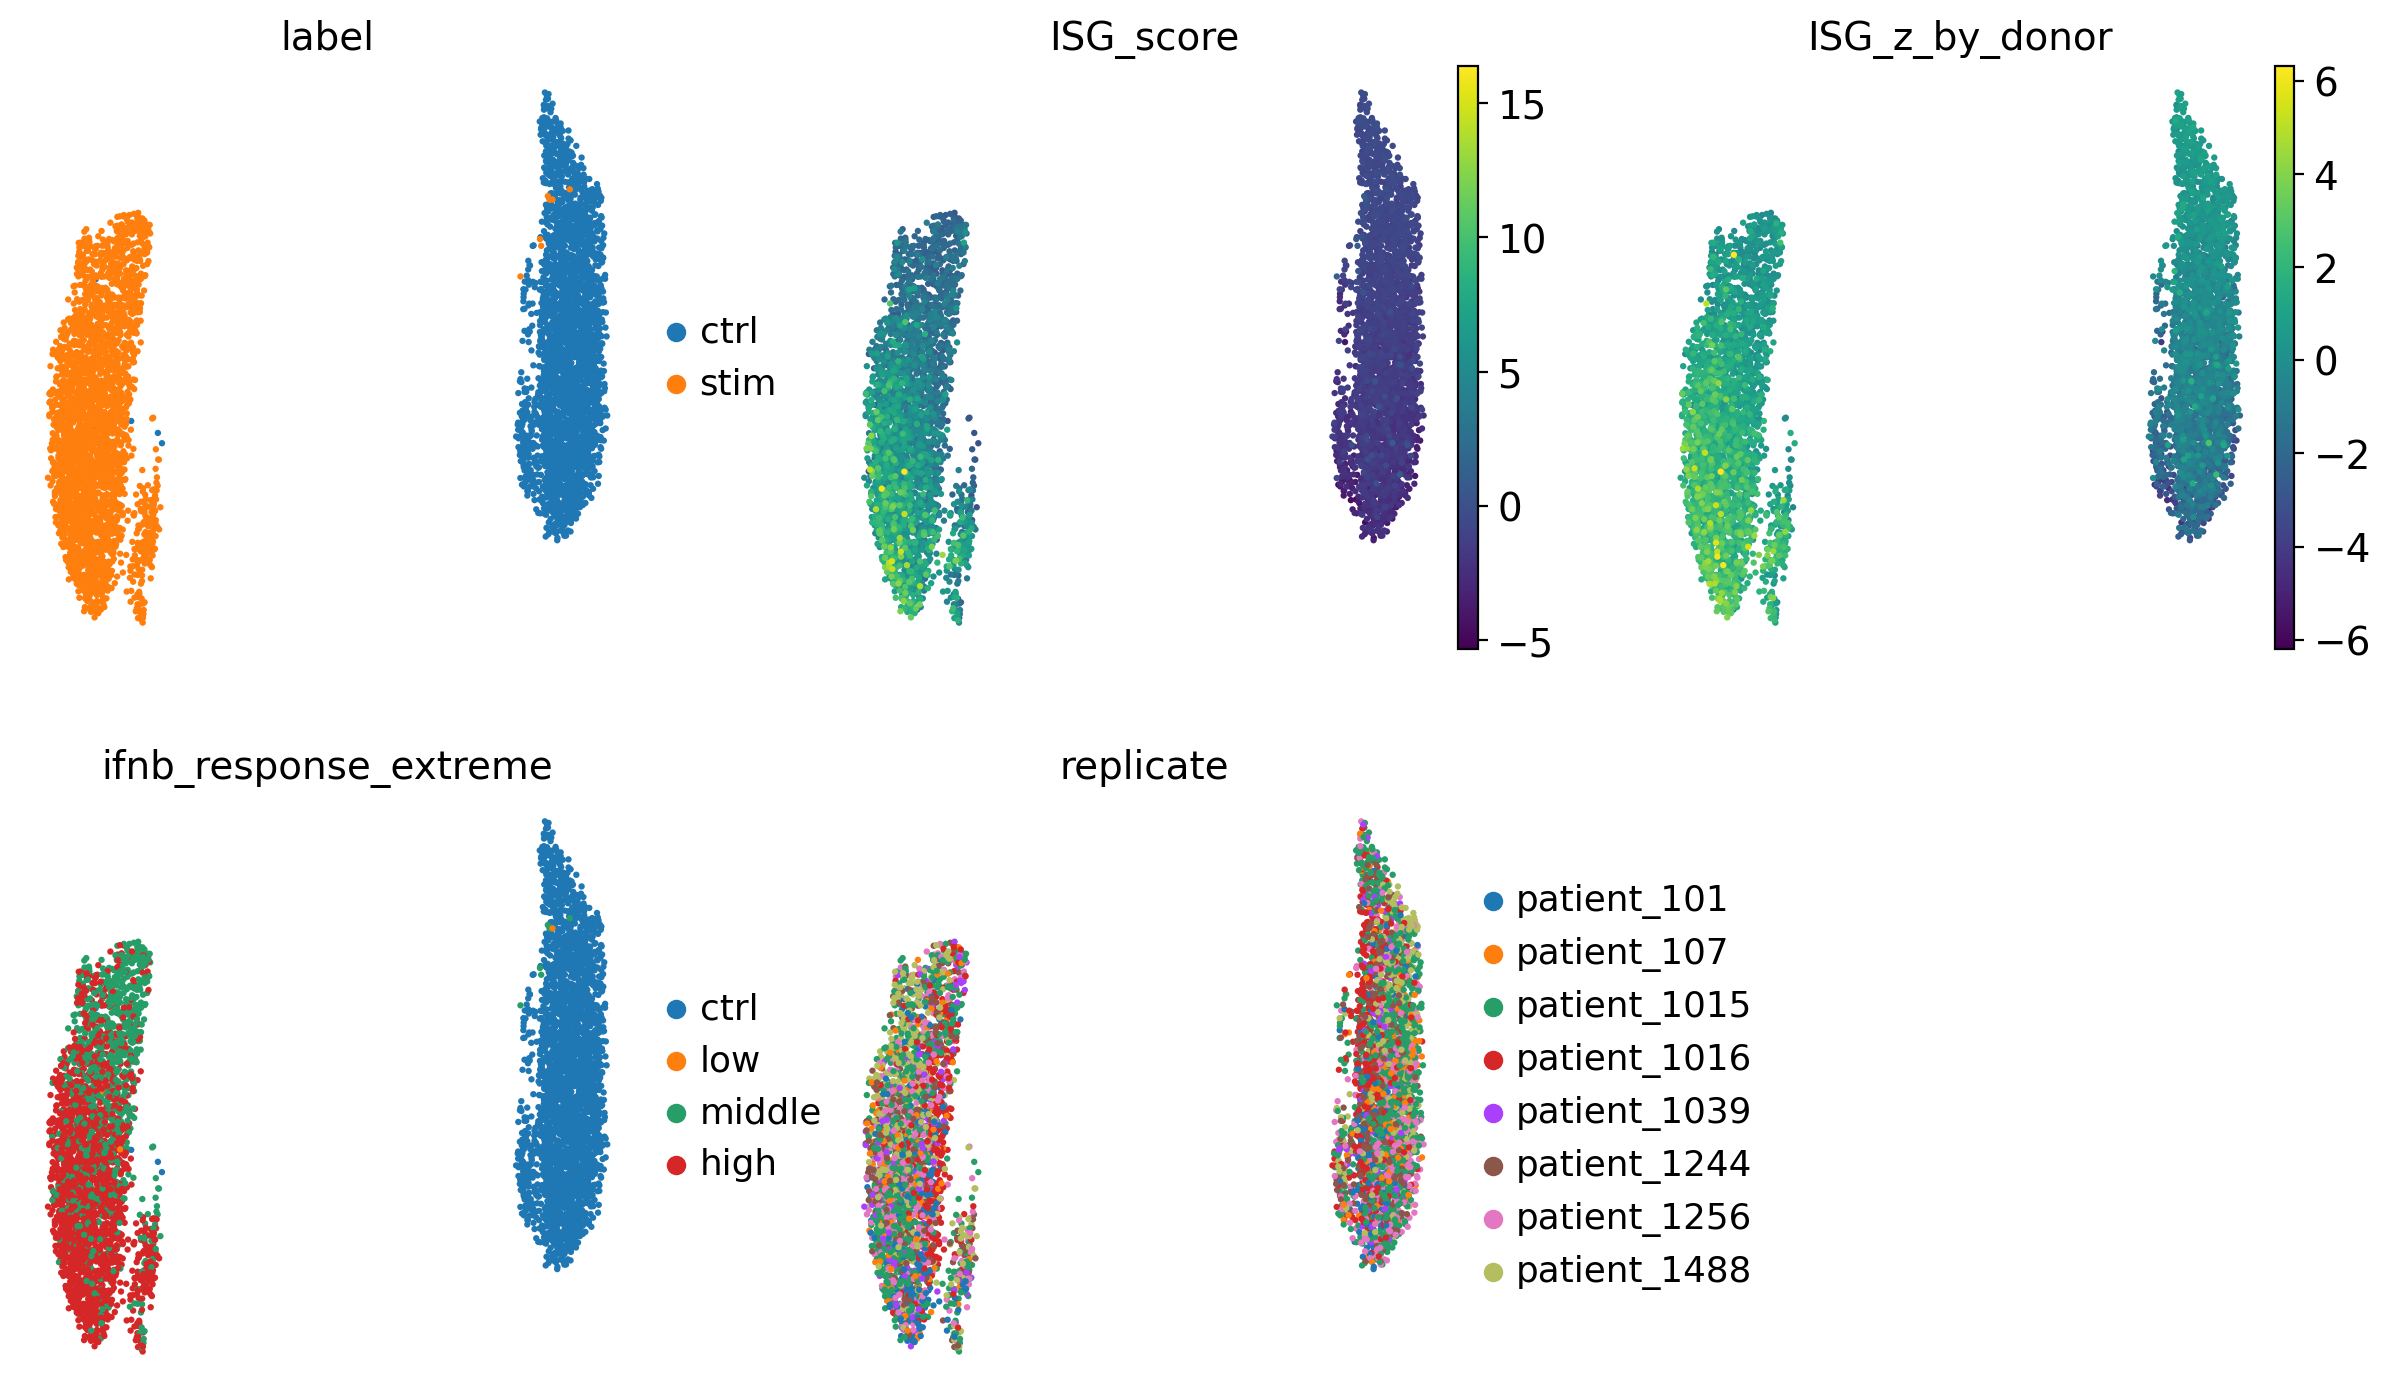

In [7]:
adata_expr = adata_cd14.copy()
sc.pp.normalize_total(adata_expr, target_sum=1e4)
sc.pp.log1p(adata_expr)
sc.pp.scale(adata_expr, max_value=10)
sc.tl.pca(adata_expr, n_comps=min(50, adata_expr.n_vars - 1), svd_solver="arpack")
sc.pp.neighbors(adata_expr, use_rep="X_pca", n_neighbors=30)
sc.tl.umap(adata_expr, min_dist=0.5)

sc.pl.embedding(
    adata_expr,
    basis="X_umap",
    color=["label", "ISG_score", "ISG_z_by_donor", "ifnb_response_extreme", "replicate"],
    ncols=3,
)

## Prepare spVIPESmulti Inputs

`ctrl` and `stim` remain the integration groups. Cell-type labels are intentionally omitted from `setup_anndata` because this is already a within-CD14 analysis.

In [8]:
adatas_dict = {}
for condition in CONDITIONS:
    sub = adata_cd14[adata_cd14.obs["label"] == condition].copy()
    sub.uns = {}
    sub.obsm = {}
    sub.layers = {}
    adatas_dict[condition] = sub
    print(f"{condition}: {sub.shape}")

adata_spv = spVIPESmulti.data.prepare_adatas(adatas_dict)

spVIPESmulti.model.spVIPESmulti.setup_anndata(
    adata_spv,
    groups_key="groups",
    sample_key="replicate",
    condition_key="label",
    donor_key="replicate",
)

group_indices_list = [list(map(int, group)) for group in adata_spv.uns["groups_obs_indices"]]
print("Group sizes:", dict(zip(CONDITIONS, [len(group) for group in group_indices_list])))

ctrl: (2932, 7494)
stim: (2765, 7494)
INFO     spVIPESmulti: === spVIPESmulti AnnData Setup ===                                                          
INFO     spVIPESmulti: Setting up with groups_key: 'groups'                                                        
INFO     spVIPESmulti: Samples: Using 'replicate' from adata.obs                                                   
INFO     spVIPESmulti: Conditions: Using 'label' from adata.obs                                                    
INFO     spVIPESmulti: Donors: Using 'replicate' from adata.obs                                                    
INFO     spVIPESmulti: --- Product of Experts (PoE) Configuration ---                                              
INFO     spVIPESmulti: No labels configured — provide label_key for PoE-based integration                          
Group sizes: {'ctrl': 2932, 'stim': 2765}


/exports/archive/hg-funcgenom-research/mdmanurung/conda/envs/scvi-test/lib/python3.13/site-packages/scvi/data/fields/_dataframe_field.py:187: UserWarning: Category 2765 in adata.obs['_scvi_indices'] has fewer than 3 cells. Models may not train properly.
  categorical_mapping = _make_column_categorical(


## Train CD14-only Shared-private Model

In [9]:
N_SHARED = 12
N_PRIVATE = 15
N_HIDDEN = 256
DROPOUT = 0.1
MAX_EPOCHS = 300
BATCH_SIZE = 1024
KL_WARMUP = 100

model = spVIPESmulti.model.spVIPESmulti(
    adata_spv,
    n_hidden=N_HIDDEN,
    n_dimensions_shared=N_SHARED,
    n_dimensions_private=N_PRIVATE,
    dropout_rate=DROPOUT,
    disentangle_preset="off",
    disentangle_group_shared_weight=1.0,
    disentangle_group_private_weight=1.0,
    disentangle_donor_shared_weight=1.0,
    disentangle_donor_private_weight=1.0,
    contrastive_weight=0.0,
    use_nf_prior=False,
    use_batch_norm=True,
    use_layer_norm=False,
    dispersion="gene-cell",
)
print(model)

INFO     spVIPESmulti: The model has been initialized                                                              


spVIPESmulti Model with the following params: 
n_hidden: 256, n_dimensions_shared: 12, n_dimensions_private: 15, dropout_rate: 0.1, multimodal: No, nf_prior: No
Training status: Not Trained

In [10]:
trainer_kwargs = {"accelerator": "gpu", "devices": 1} if torch.cuda.is_available() else {}

model.train(
    group_indices_list=group_indices_list,
    batch_size=BATCH_SIZE,
    max_epochs=MAX_EPOCHS,
    train_size=0.9,
    early_stopping=False,
    n_epochs_kl_warmup=KL_WARMUP,
    compute_orthogonality_metric=True,
    orthogonality_groupby_keys=("condition", "donor"),
    orthogonality_min_cells_per_stratum=16,
    plan_kwargs={
        "lr_scheduler_type": "cosine",
        "lr_patience": 50,
    },
    **trainer_kwargs,
)

/exports/archive/hg-funcgenom-research/mdmanurung/conda/envs/scvi-test/lib/python3.13/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /exports/archive/hg-funcgenom-research/mdmanurung/co ...
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/exports/archive/hg-funcgenom-research/mdmanurung/conda/envs/scvi-test/lib/python3.13/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with

Training:   0%|          | 0/300 [00:00<?, ?it/s]

/exports/para-lipg-hpc/mdmanurung/spVIPESmulti/src/spVIPESmulti/module/spVIPESmultimodule.py:1575: UserWarning: The value argument must be within the support of the distribution
  recon_loss = -generative_outputs["private_poe"][str(g)]["px"].log_prob(x_target).sum(-1)
/exports/para-lipg-hpc/mdmanurung/spVIPESmulti/src/spVIPESmulti/module/spVIPESmultimodule.py:1575: UserWarning: The value argument must be within the support of the distribution
  recon_loss = -generative_outputs["private_poe"][str(g)]["px"].log_prob(x_target).sum(-1)
/exports/para-lipg-hpc/mdmanurung/spVIPESmulti/src/spVIPESmulti/module/spVIPESmultimodule.py:1575: UserWarning: The value argument must be within the support of the distribution
  recon_loss = -generative_outputs["private_poe"][str(g)]["px"].log_prob(x_target).sum(-1)
/exports/para-lipg-hpc/mdmanurung/spVIPESmulti/src/spVIPESmulti/module/spVIPESmultimodule.py:1575: UserWarning: The value argument must be within the support of the distribution
  recon_loss = 

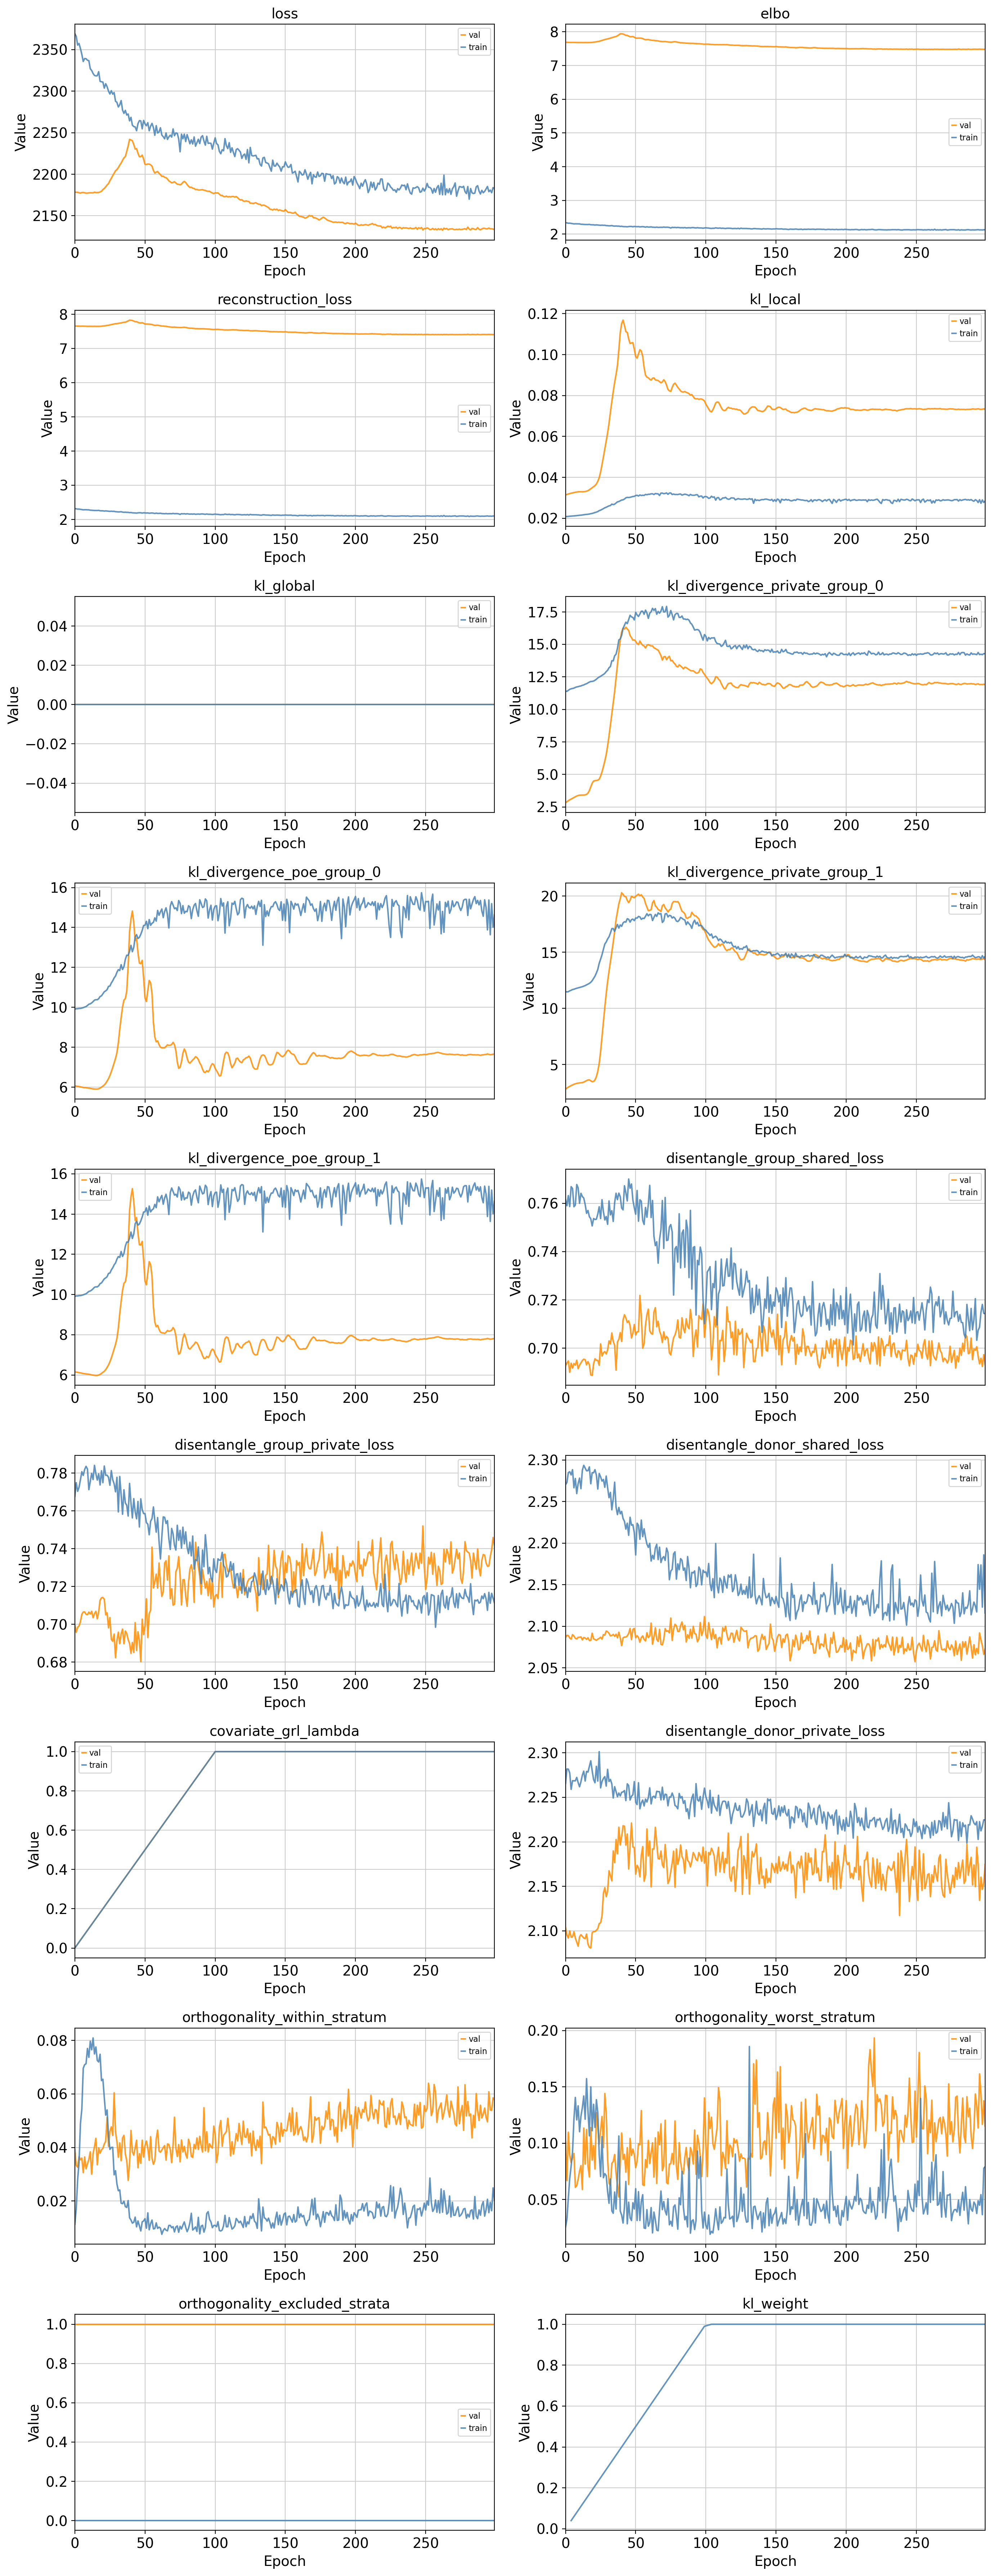

In [11]:
fig = spVIPESmulti.pl.training_curves(model)
plt.show()

## Rank Latent Factors by IFNb Response Association

The stimulated private latent is the main object for IFNb-specific programs. A strong response factor should correlate with donor-adjusted `ISG_z_by_donor` and separate high-vs-low stimulated response quantiles.

In [12]:
payload = model.embed(
    group_indices_list=group_indices_list,
    batch_size=BATCH_SIZE,
    overwrite=True,
)

shared_key = payload["keys"]["shared"]
private_keys = payload["keys"]["private"]
private_stim_key = private_keys.get("stim")
if private_stim_key is None:
    raise KeyError(f"Could not find a stimulated private key. Available keys: {private_keys}")

private_stitched_key = "X_spvm_private_stitched"
private_stitched = np.zeros_like(next(iter(payload["private"].values())))
for private_arr in payload["private"].values():
    private_stitched += private_arr
adata_spv.obsm[private_stitched_key] = private_stitched

stim_mask_spv = adata_spv.obs["groups"].astype(str).to_numpy() == "stim"
adata_spv_stim = adata_spv[stim_mask_spv].copy()

print("shared key       :", shared_key)
print("stim private key :", private_stim_key)
print("stim shape       :", adata_spv_stim.shape)

shared key       : X_spvm_shared
stim private key : X_spvm_private_stim
stim shape       : (2765, 14988)


In [13]:
probe_rows = []
for latent_name, obsm_key in {
    "shared": shared_key,
    "private_stitched": private_stitched_key,
}.items():
    x = np.asarray(adata_spv.obsm[obsm_key])
    for target_name, obs_key in {
        "condition": "label",
        "donor": "replicate",
        "response_extreme": "ifnb_response_extreme",
    }.items():
        probe_rows.append({
            "latent": latent_name,
            "target": target_name,
            "balanced_accuracy": probe_balanced_accuracy(x, adata_spv.obs[obs_key]),
        })

probe_df = pd.DataFrame(probe_rows)
probe_df.to_csv(RESULTS_DIR / "latent_probe_balanced_accuracy.csv", index=False)
probe_df.pivot(index="target", columns="latent", values="balanced_accuracy")

latent,private_stitched,shared
target,,
condition,0.610645,0.487123
donor,0.171916,0.143915
response_extreme,0.472908,0.299574


In [14]:
private_response = latent_response_summary(adata_spv_stim, private_stim_key)
shared_response = latent_response_summary(adata_spv_stim, shared_key)

private_response.to_csv(RESULTS_DIR / "stim_private_response_factor_summary.csv", index=False)
shared_response.to_csv(RESULTS_DIR / "stim_shared_response_factor_summary.csv", index=False)

print("Top stimulated private dimensions by donor-adjusted IFNb response:")
print(private_response.head(10).to_string(index=False))

print("\nTop stimulated shared dimensions by donor-adjusted IFNb response:")
print(shared_response.head(10).to_string(index=False))

Top stimulated private dimensions by donor-adjusted IFNb response:
 dim  spearman_r  spearman_abs    spearman_p  auc_high_vs_low  auc_directionless
   5    0.545028      0.545028 9.233390e-214         0.858590           0.858590
  14   -0.534887      0.534887 1.776060e-204         0.076850           0.923150
   1   -0.532749      0.532749 1.465087e-202         0.073474           0.926526
   4    0.524537      0.524537 2.527265e-195         0.912885           0.912885
  12   -0.524485      0.524485 2.805009e-195         0.129390           0.870610
   9    0.520680      0.520680 5.419402e-192         0.902755           0.902755
  11    0.514631      0.514631 7.439721e-187         0.925986           0.925986
   6   -0.509679      0.509679 1.002515e-182         0.239060           0.760940
   0   -0.505513      0.505513 2.647303e-179         0.060373           0.939627
   7   -0.503952      0.503952 4.937240e-178         0.215964           0.784036

Top stimulated shared dimensions by donor

## Visualize Stimulated Private Response Factors

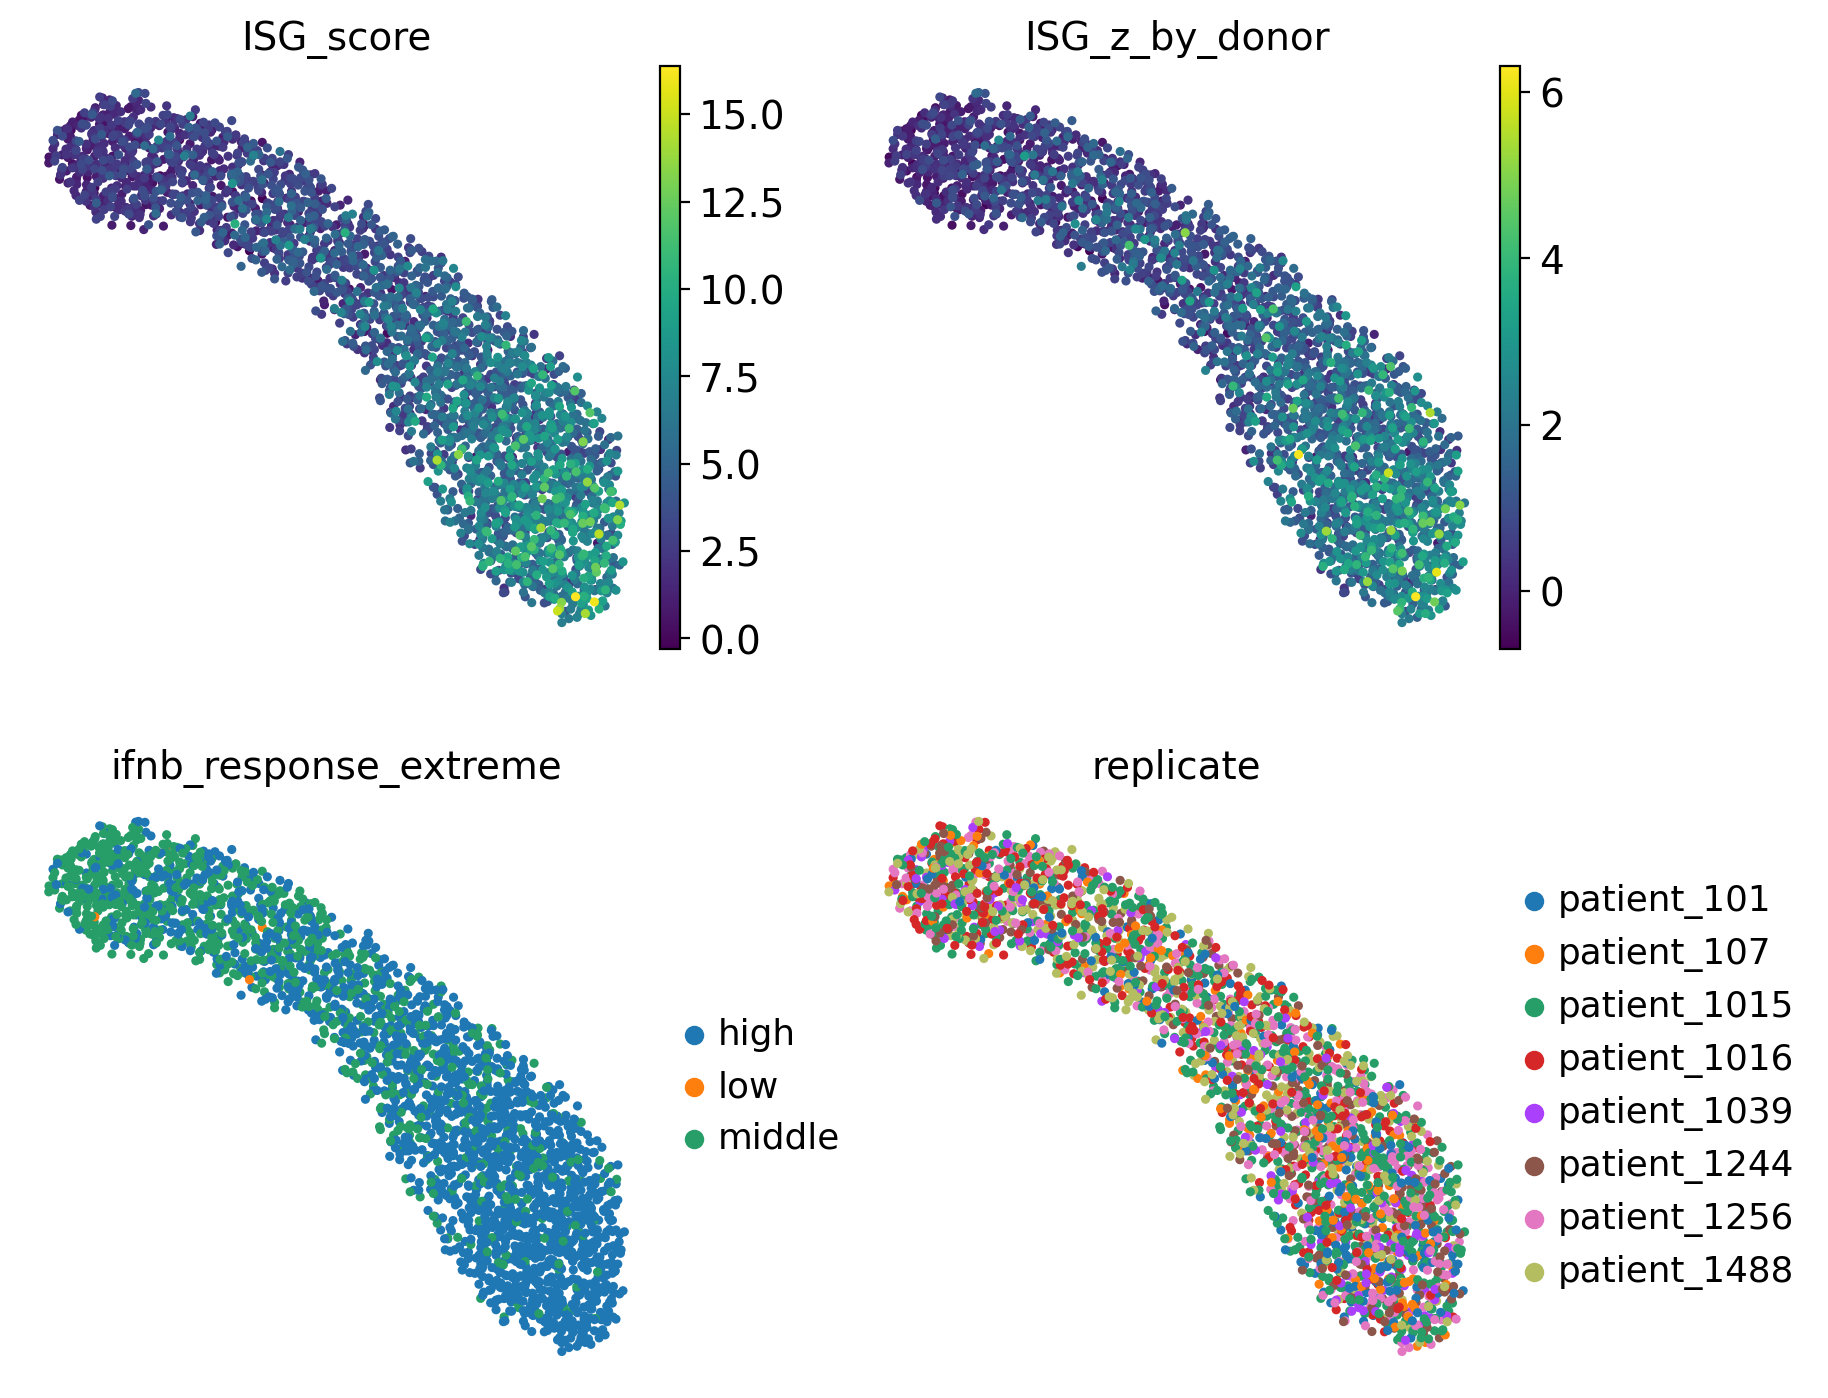

In [15]:
sc.pp.neighbors(
    adata_spv_stim,
    use_rep=private_stim_key,
    key_added="spvm_private_stim",
    n_neighbors=30,
)
sc.tl.umap(adata_spv_stim, neighbors_key="spvm_private_stim", min_dist=0.5)

sc.pl.embedding(
    adata_spv_stim,
    basis="X_umap",
    color=["ISG_score", "ISG_z_by_donor", "ifnb_response_extreme", "replicate"],
    ncols=2,
)

Top private response dimensions: [5, 14, 1, 4, 12, 9]


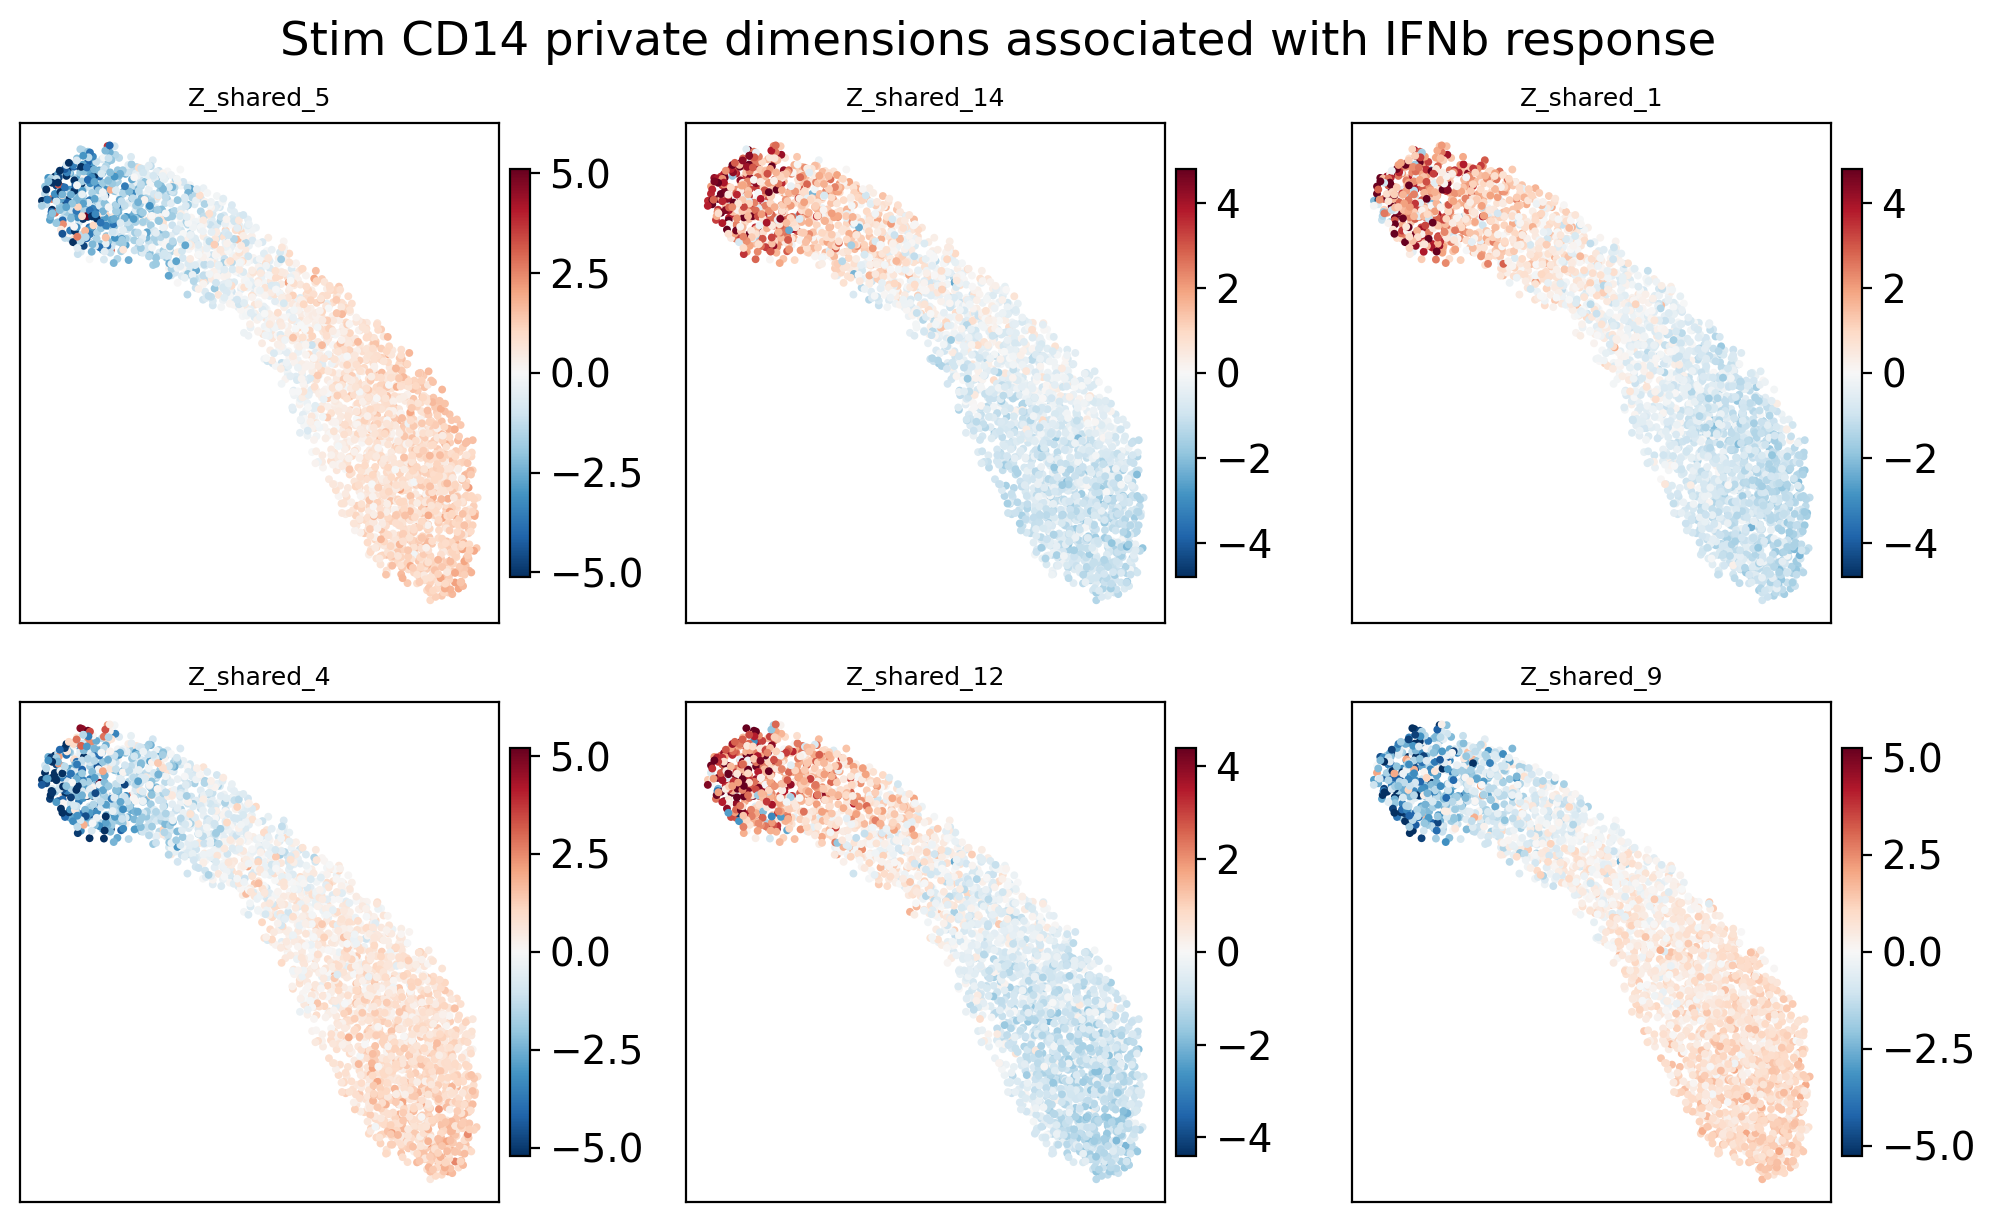

In [16]:
top_private_dims = private_response.head(6)["dim"].astype(int).tolist()
print("Top private response dimensions:", top_private_dims)

fig = spVIPESmulti.pl.plot_latent_dims_in_umap(
    adata_spv_stim,
    obsm_key=private_stim_key,
    dims=top_private_dims,
    ncols=3,
    figsize_per_panel=(3.4, 3.0),
)
fig.suptitle("Stim CD14 private dimensions associated with IFNb response", y=1.02)
plt.show()

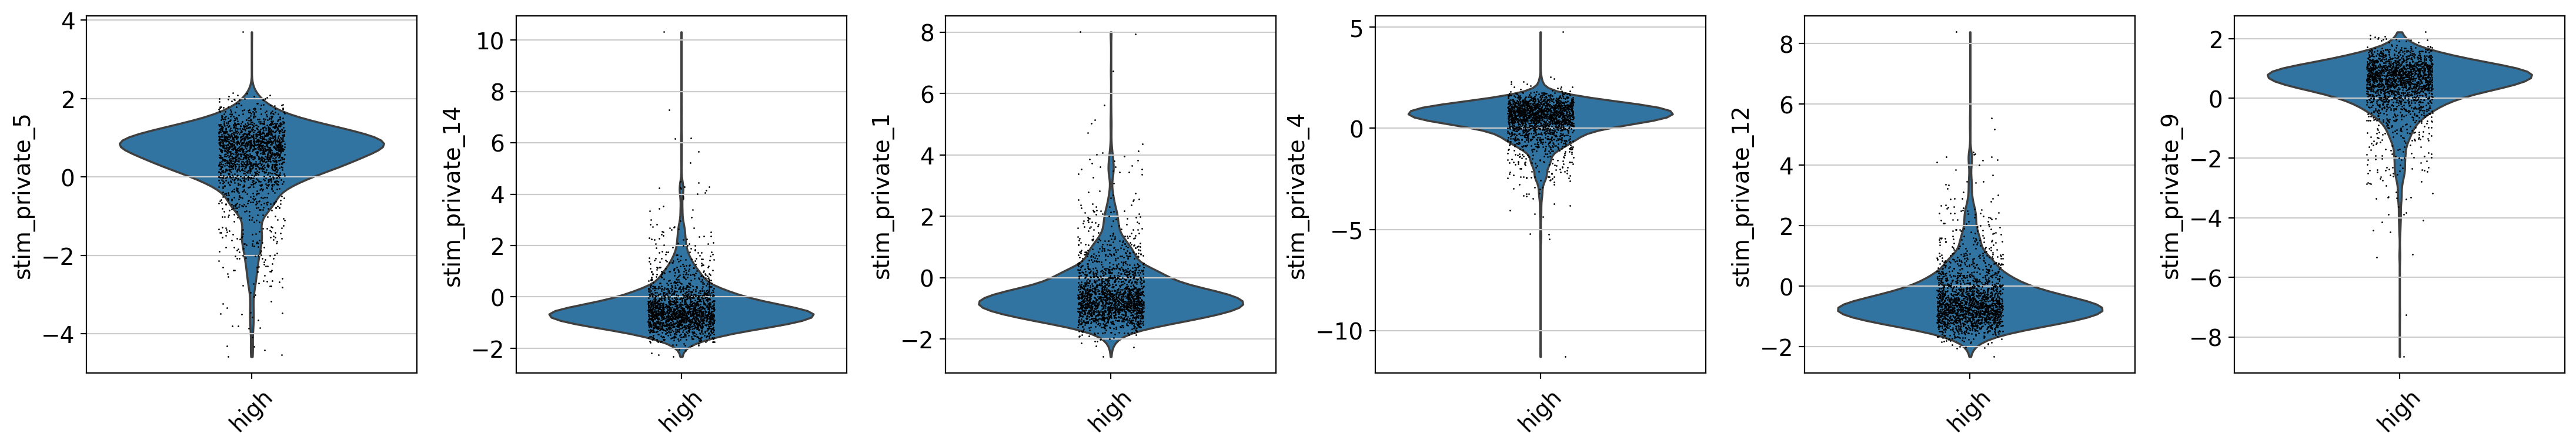

In [17]:
for dim_idx in top_private_dims:
    adata_spv_stim.obs[f"stim_private_{dim_idx}"] = adata_spv_stim.obsm[private_stim_key][:, dim_idx]

extreme_stim = adata_spv_stim[
    adata_spv_stim.obs["ifnb_response_extreme"].isin(["medium", "high"])
].copy()

sc.pl.violin(
    extreme_stim,
    keys=[f"stim_private_{dim_idx}" for dim_idx in top_private_dims],
    groupby="ifnb_response_extreme",
    rotation=45,
    multi_panel=True,
)

## Interpret Response-associated Gene Programs

Loadings are inspected after selecting response-associated dimensions. `high_response_genes` flips the signed loading direction when a latent factor is negatively correlated with `ISG_z_by_donor`.

In [18]:
top_stim = spVIPESmulti.utils.get_top_genes(
    model=model,
    group_idx=CONDITIONS.index("stim"),
    latent_type="private",
    n_top=50,
    signed=True,
)
 
program_table = response_program_table(top_stim, private_response, n_dims=6)
program_table.to_csv(RESULTS_DIR / "stim_private_response_programs.csv", index=False)
program_table[["dim", "spearman_r", "auc_high_vs_low", "high_response_genes", "low_response_genes"]]

,dim,spearman_r,auc_high_vs_low,high_response_genes,low_response_genes
0,Z_private_1,-0.532749,0.073474,"[EIF4A3, TAP2.1, UBAP1, RHOA, AHSA1, MYO1E, SL...","[ASXL2, FKBP8, SEC31A, AC018816.3, APEX1, DTYM..."
1,Z_private_4,0.524537,0.912885,"[C17orf62, TUFM, PLD3, SNRPD3, CD163, KDM3B, A...","[NAPRT1, CTB-61M7.2, DRG2, SFSWAP, ZNF230, KDM..."
2,Z_private_5,0.545028,0.858590,"[COX4I1, YARS, POR, NRBP1, MED8, NSMAF, TNS1, ...","[FGD4, PMM1, LINC00996, SPTAN1, NDRG1, SLC11A2..."
3,Z_private_9,0.520680,0.902755,"[ACTR2, HIGD2A, KCNMA1, ITGB1BP1, MBOAT7, FPGS...","[C16orf62, PLEKHA2, CCDC115, HIST1H2BD, GMIP, ..."
4,Z_private_12,-0.524485,0.129390,"[ABT1, DAPP1, PPWD1, XRN2, SH3KBP1, NOSIP, SCA...","[RNF19B, HCAR2, SPCS1, KLHL36, PPFIA1, KIAA031..."
5,Z_private_14,-0.534887,0.076850,"[ST13, RRAGD, ORMDL2, C16orf62, ALDH9A1, QARS,...","[C1orf54, SRP72, TMEM18, PREP, SIRPA, CCDC104,..."


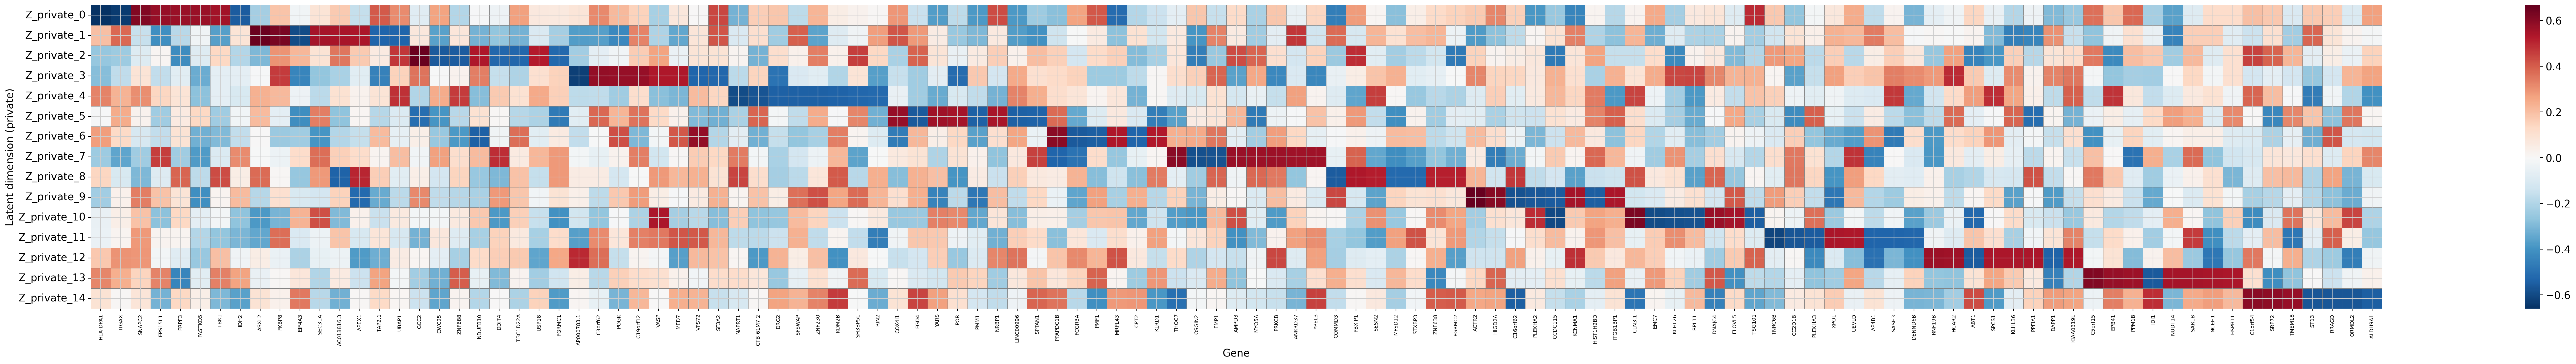

In [19]:
ax = spVIPESmulti.pl.heatmap_loadings(
    model=model,
    group_idx=CONDITIONS.index("stim"),
    latent_type="private",
    n_top=8,
)
plt.show()

/tmp/ipykernel_2845787/1528536661.py:6: UserWarning: Some cells have zero counts
  sc.pp.normalize_total(adata_program_plot, target_sum=1e4)


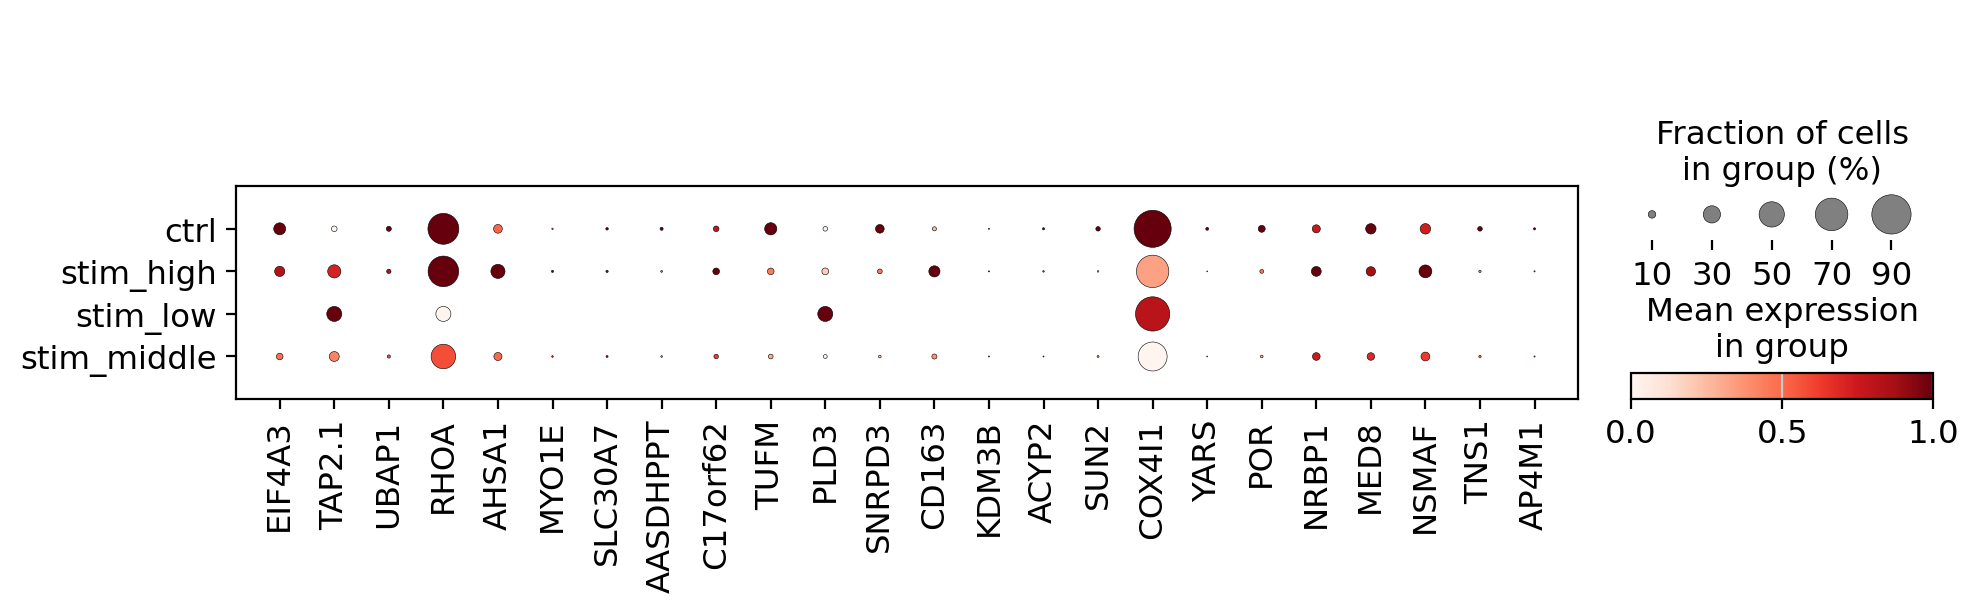

In [20]:
program_genes = first_n_genes(program_table["high_response_genes"].head(3), n_per_list=8)
program_genes = [gene for gene in program_genes if gene in adata_cd14.var_names]

if program_genes:
    adata_program_plot = adata_cd14[:, program_genes].copy()
    sc.pp.normalize_total(adata_program_plot, target_sum=1e4)
    sc.pp.log1p(adata_program_plot)
    adata_program_plot.obs["condition_response"] = adata_program_plot.obs["label"].astype(str)
    stim_idx = adata_program_plot.obs["label"].astype(str) == "stim"
    adata_program_plot.obs.loc[stim_idx, "condition_response"] = (
        "stim_" + adata_program_plot.obs.loc[stim_idx, "ifnb_response_extreme"].astype(str)
    )
    sc.pl.dotplot(
        adata_program_plot,
        var_names=program_genes,
        groupby="condition_response",
        standard_scale="var",
    )
else:
    print("No response-program genes were found in adata_cd14.var_names.")

## Output Files

The notebook writes these tables under `docs/notebooks/results/kang_ifn_cd14_gene_programs/`:

- `cd14_stim_vs_ctrl_de.csv`: raw-expression CD14 stim-vs-ctrl differential-expression sanity check
- `latent_probe_balanced_accuracy.csv`: simple diagnostic probes of latent encodings
- `stim_private_response_factor_summary.csv`: response association metrics for stimulated private factors
- `stim_shared_response_factor_summary.csv`: response association metrics for shared factors
- `stim_private_response_programs.csv`: signed loading-derived IFNb response gene programs